## Course development analysis
This project focuses on the development of the courses, esp. their enrolments and acquired certificats 

In [7]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import timedelta

In [8]:
# Use the cleaned Excel sheet!!!
# define a list of sheet names

dates_str = ['27.04.2026', '27.03.2026', '27.02.2026', '28.01.2026', '19.12.2025', '27.11.2025', '28.10.2025', '26.09.2025', '26.08.2025', '28.07.2025', '23.06.2025', '21.05.2025']


In [9]:
# import data by looping over the sheet names

course_df = pd.DataFrame()

for sheet_str in dates_str:
    import_path = 'C:/Users/ywa/Dokumente/Data/Course_success_tracking/course_success_tracking.xlsx'
    df = pd.read_excel(import_path, sheet_name = sheet_str)
    df['date'] = sheet_str
    df['date'] =  pd.to_datetime(df['date'], format = '%d.%m.%Y')
    df['month'] = df['date'].dt.month
    course_df = pd.concat([course_df, df], axis = 0, ignore_index = True) 
    
course_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1057 entries, 0 to 1056
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   courseID                                   1057 non-null   int64         
 1   Live Courses                               1057 non-null   object        
 2   Course Category                            1057 non-null   object        
 3   Enrolled learners                          1057 non-null   int64         
 4   Acquired # Comfirmation of Participations  1044 non-null   float64       
 5   Acquired # Records of Achievement          1038 non-null   float64       
 6   Rate CoP                                   1052 non-null   float64       
 7   Rate RoA (success)                         1050 non-null   float64       
 8   date                                       1057 non-null   datetime64[ns]
 9   month              

In [10]:
# change the column names --> too wordy

course_df.columns = ['courseID', 'Live Courses', 'Course Category', 'Enrolled learners', 'CoP', 'RoA', 'Rate CoP', 'Rate RoA', 'date', 'month']

course_df.head()


,courseID,Live Courses,Course Category,Enrolled learners,CoP,RoA,Rate CoP,Rate RoA,date,month
0,106,Einführung in die KI,Über KI,19935,3155.0,2548.0,0.16,0.13,2026-04-27,4
1,58,AICE your exams – Generative KI als Copilot im...,Studieren,13754,9498.0,5225.0,0.69,0.38,2026-04-27,4
2,99,KI für Alle 1: Einführung in die Künstliche In...,Über KI,8664,720.0,555.0,0.08,0.06,2026-04-27,4
3,313,EU AI Act Essentials,Studieren,8074,2760.0,2133.0,0.34,0.26,2026-04-27,4
4,197,KIÖV - KI in öffentlichen Verwaltungen,Studieren,5952,2955.0,2556.0,0.50,0.43,2026-04-27,4


In [11]:
# the latest date for indexing
latest_date = course_df.loc[:, 'date'][0]

latest_date

Timestamp('2026-04-27 00:00:00')

## Enrolment & certificates

In [12]:
# create table of enrolment

monthly_enrol = course_df.groupby('date')[['Enrolled learners', 'CoP', 'RoA']].agg(sum)

monthly_enrol


C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\834444531.py:3: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  monthly_enrol = course_df.groupby('date')[['Enrolled learners', 'CoP', 'RoA']].agg(sum)


,Enrolled learners,CoP,RoA
date,,,
2025-05-21,55507,8893.0,6840.0
2025-06-23,61764,10380.0,7938.0
2025-07-28,69711,12154.0,9359.0
2025-08-26,76808,13843.0,10756.0
2025-09-26,86982,15783.0,12284.0
2025-10-28,99671,17950.0,14051.0
2025-11-27,111626,20839.0,16425.0
2025-12-19,122197,24159.0,18930.0
2026-01-28,140990,33822.0,25666.0


In [13]:
# calculate the changes per month --> via function 

def rate_enrol_cert(df):
    df['rate_enrol'] = df['Enrolled learners'].pct_change()
    df['rate_CoP'] = df['CoP'].pct_change()
    df['rate_RoA'] = df['RoA'].pct_change()
    return df

monthly_enrol = rate_enrol_cert(monthly_enrol)

monthly_enrol


,Enrolled learners,CoP,RoA,rate_enrol,rate_CoP,rate_RoA
date,,,,,,
2025-05-21,55507,8893.0,6840.0,NaN,NaN,NaN
2025-06-23,61764,10380.0,7938.0,0.112725,0.167210,0.160526
2025-07-28,69711,12154.0,9359.0,0.128667,0.170906,0.179012
2025-08-26,76808,13843.0,10756.0,0.101806,0.138967,0.149268
2025-09-26,86982,15783.0,12284.0,0.132460,0.140143,0.142060
2025-10-28,99671,17950.0,14051.0,0.145881,0.137300,0.143846
2025-11-27,111626,20839.0,16425.0,0.119945,0.160947,0.168956
2025-12-19,122197,24159.0,18930.0,0.094700,0.159317,0.152511
2026-01-28,140990,33822.0,25666.0,0.153793,0.399975,0.355837


<Axes: >

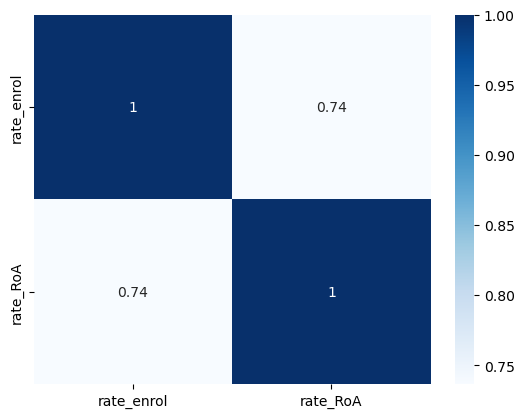

In [14]:
# rate correlation

enrol_cert_change = monthly_enrol[['rate_enrol', 'rate_RoA']].corr()

sns.heatmap(enrol_cert_change, annot = True, cmap = 'Blues') # moderate positive correalation between percentage of enrollment and percentage of RoA


In [15]:
# enrolment rate & RoA rate

print('The highest enrolment rate was:',round(monthly_enrol['rate_enrol'].max(), 2), 'in month', monthly_enrol['rate_enrol'].idxmax())
print('The lowest enrolment rate was:', round(monthly_enrol['rate_enrol'].min(), 2), 'in month', monthly_enrol['rate_enrol'].idxmin())

print('The highest RoA rate was:',round(monthly_enrol['rate_RoA'].max(), 2), 'in month', monthly_enrol['rate_RoA'].idxmax())
print('The lowest RoA rate was:', round(monthly_enrol['rate_RoA'].min(), 2), 'in month', monthly_enrol['rate_RoA'].idxmin())



The highest enrolment rate was: 0.15 in month 2026-01-28 00:00:00
The lowest enrolment rate was: 0.07 in month 2026-03-27 00:00:00
The highest RoA rate was: 0.36 in month 2026-01-28 00:00:00
The lowest RoA rate was: 0.08 in month 2026-04-27 00:00:00


C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\1109179445.py:9: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(monthly_enrol.index, monthly_enrol["rate_enrol"], color="blue", label="Enrolment_rate", linestyle="-")
C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\1109179445.py:10: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(monthly_enrol.index, monthly_enrol["rate_RoA"], color="green", label="RoA_rate", linestyle="-")


<Figure size 1600x800 with 0 Axes>

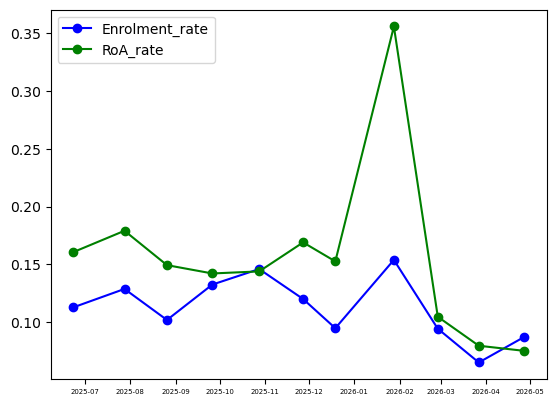

In [16]:
# plotting enrol rate & RoA rate

plt.figure(figsize = (16, 8))
fig, ax = plt.subplots()

x_col='Date'
y_col = 'Rate'

ax.plot_date(monthly_enrol.index, monthly_enrol["rate_enrol"], color="blue", label="Enrolment_rate", linestyle="-")
ax.plot_date(monthly_enrol.index, monthly_enrol["rate_RoA"], color="green", label="RoA_rate", linestyle="-")
ax.tick_params(axis='x', labelsize = 5)

ax.legend()


# Correlation among all courses and roa

<Axes: xlabel='Enrolled learners', ylabel='RoA'>

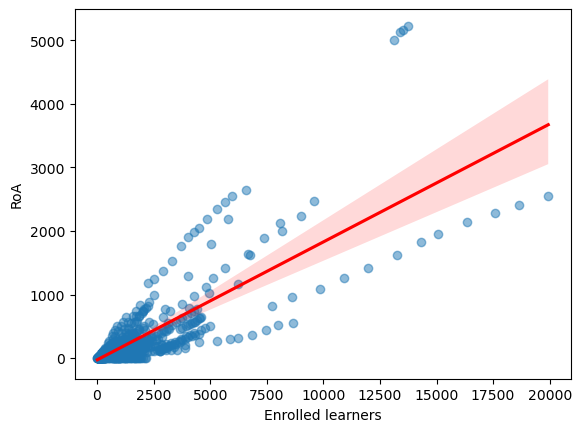

In [17]:
# Scatter plot

sns.regplot(data = course_df, x = 'Enrolled learners', y = 'RoA', scatter_kws = {'alpha' : 0.5}, line_kws = {'color' : 'red', 'label' : 'Trend line'})

In [18]:
# calculation of the correlation value
corr_enrol_roa = course_df['Enrolled learners'].corr(course_df['RoA'])

print('Correlation between enrolment and RoA:', corr_enrol_roa)

Correlation between enrolment and RoA: 0.8080440409904642


## top 10 Enrolments and RoA -- average growth

In [19]:
# group the table based on the courses

enrol_by_course = course_df.groupby(['courseID', 'Live Courses', 'Course Category'])[['Enrolled learners', 'RoA', 'Rate RoA']].agg(np.mean)

enrol_by_course.columns = ['Avg_enrol', 'Avg_RoA', 'Avg_rate_RoA']

enrol_by_course['Avg_enrol'] = round(enrol_by_course['Avg_enrol'], 0)

enrol_by_course['Avg_RoA'] = round(enrol_by_course['Avg_RoA'], 2)

enrol_by_course['Avg_rate_RoA'] = round(enrol_by_course['Avg_rate_RoA'], 2)

enrol_by_course_id = enrol_by_course.reset_index()

enrol_by_course = enrol_by_course_id.set_index('Live Courses')

enrol_by_course

C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\575310330.py:3: FutureWarning: The provided callable <function mean at 0x000002088FA47EC0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  enrol_by_course = course_df.groupby(['courseID', 'Live Courses', 'Course Category'])[['Enrolled learners', 'RoA', 'Rate RoA']].agg(np.mean)


,courseID,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA
Live Courses,,,,,
Introduction to Machine Learning Part 1: Foundations,6,Maschinelles Lernen,1567.0,86.67,0.06
Dr. med. KI - Ethics,10,Medizin,609.0,172.42,0.28
Sprachassistenzen als Chance für die Hochschullehre,19,Erwachsenenbildung,4188.0,559.42,0.13
Identifikation geeigneter KI-Anwendungsfälle,27,Industrie 4.0,3636.0,281.92,0.08
Künstliche Intelligenz im Handel,28,Handel,1412.0,223.25,0.16
...,...,...,...,...,...
Die Welt der Daten,386,Über KI,820.0,75.57,0.08
Agentic AI: The New Software Paradigm,393,Maschinelles Lernen,691.0,57.33,0.08
Transformer-basierte Large Language Models verstehen,394,Maschinelles Lernen,557.0,20.00,0.04


In [20]:
# plotting function

def plot_topX_horizontal(title, series, xlabel, x = 10, show_values = False):
    plt.figure(figsize = (14, 8))
    
    series = series.sort_values(ascending = False)
    ax = series.iloc[: x].iloc[: : -1].plot(kind="barh")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Course Name')
    plt.grid(axis = 'x')
    
    # show values
    if show_values == True:
        for bar in ax.patches:
            width = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2
            ax.text(width, y, f'{width:.2f}', va = 'center', ha = 'left', color = 'black', fontweight = 'bold', fontsize = 10, clip_on = False)
        
    plt.tight_layout()
    plt.show()

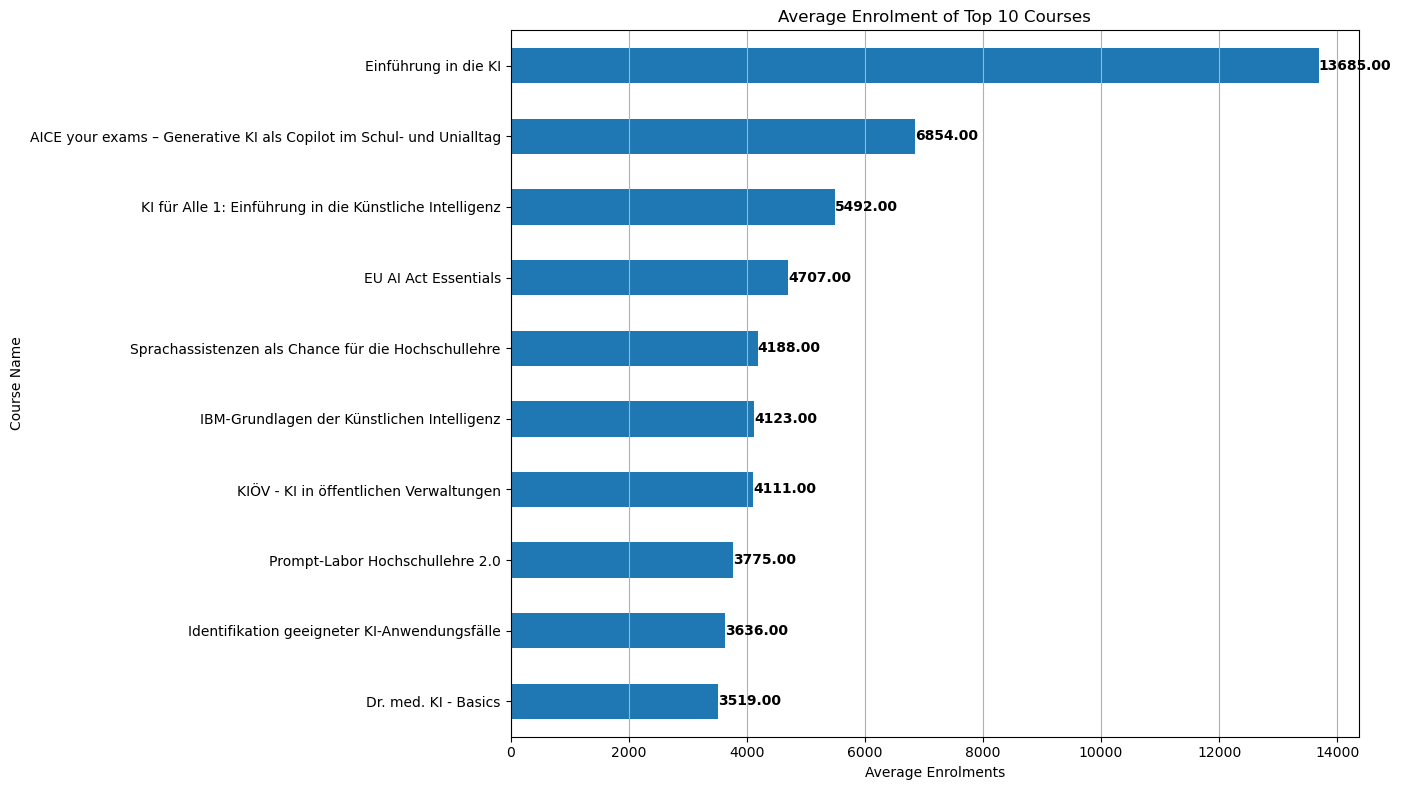

In [21]:
#  ranking base on the three differnt variables

# ranking based on Avg_enrol
plot_topX_horizontal('Average Enrolment of Top 10 Courses', enrol_by_course['Avg_enrol'], xlabel = 'Average Enrolments', show_values = True)


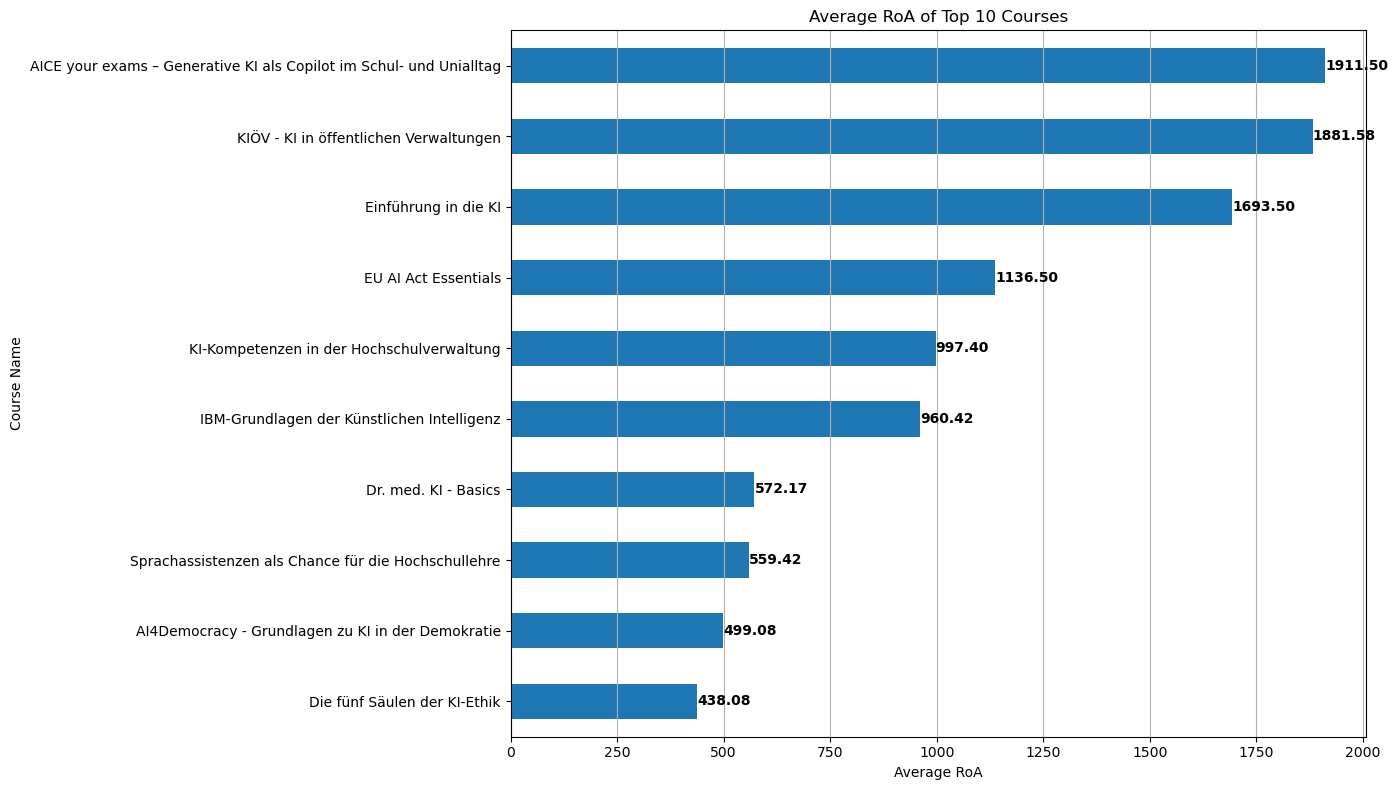

In [22]:
# ranking based on Avg_RoA
plot_topX_horizontal('Average RoA of Top 10 Courses', enrol_by_course['Avg_RoA'], xlabel = 'Average RoA', show_values = True)


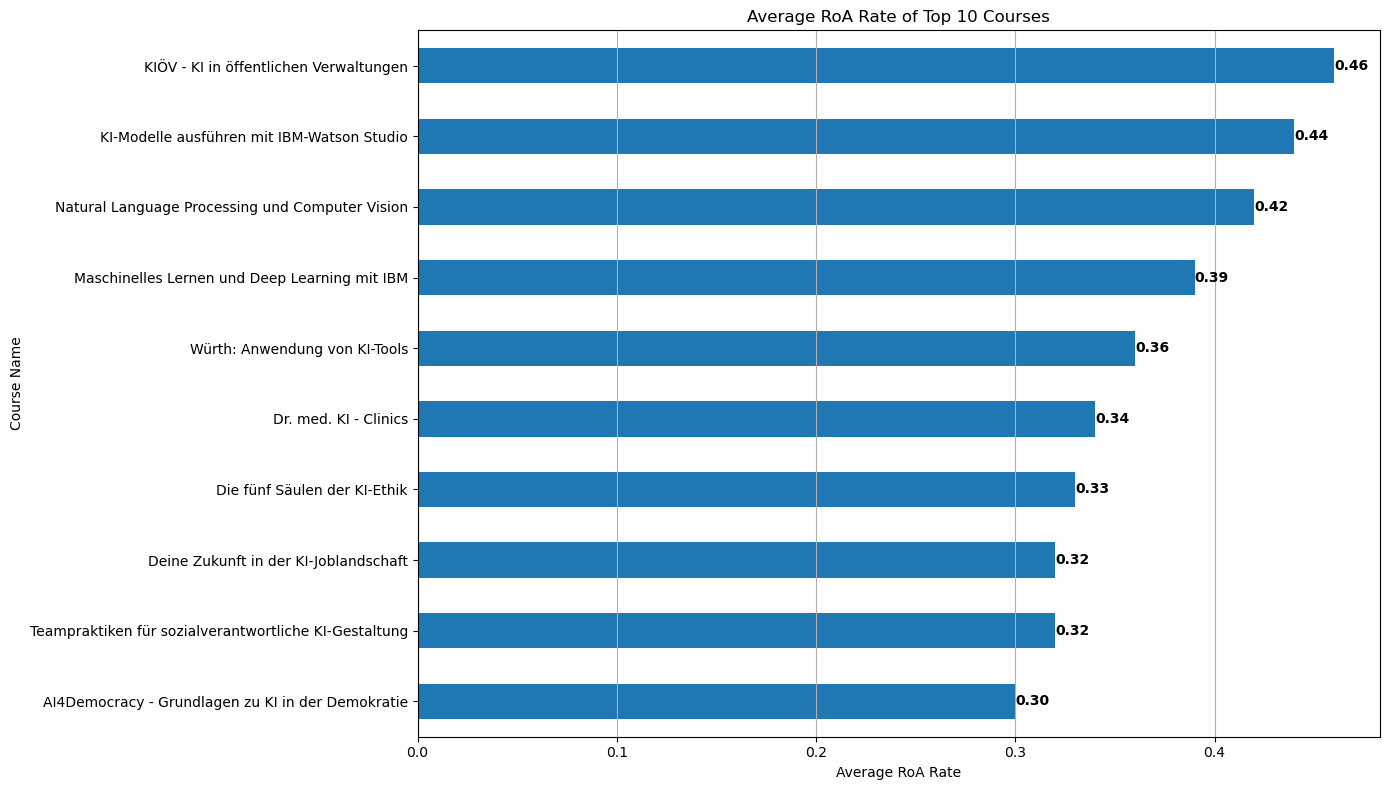

In [23]:
# Ranking based on RoA_Rate
plot_topX_horizontal('Average RoA Rate of Top 10 Courses', enrol_by_course['Avg_rate_RoA'], xlabel = 'Average RoA Rate', show_values = True)


## Time series of top 10

In [24]:
# getting indicies of the top 10 --> list of coures names

# avg enrol
top_10_enrol = enrol_by_course['Avg_enrol'].sort_values(ascending = False).head(10).index

# avg RoA
top_10_RoA = enrol_by_course['Avg_RoA'].sort_values(ascending = False).head(10).index

# avg rate RoA
top_10_rate_RoA = enrol_by_course['Avg_rate_RoA'].sort_values(ascending = False).head(10).index



In [25]:
# index top courses

# top enrol
top10_enrol_allTime = course_df[course_df['Live Courses'].isin(top_10_enrol)]

top10_enrol_allTime.head()

# pivot table

top10_enrol_allTime_pivot = top10_enrol_allTime.pivot(index = 'date', columns = 'Live Courses', values = 'Enrolled learners')

top10_enrol_allTime_pivot.head()


Live Courses,AICE your exams – Generative KI als Copilot im Schul- und Unialltag,Dr. med. KI - Basics,EU AI Act Essentials,Einführung in die KI,IBM-Grundlagen der Künstlichen Intelligenz,Identifikation geeigneter KI-Anwendungsfälle,KI für Alle 1: Einführung in die Künstliche Intelligenz,KIÖV - KI in öffentlichen Verwaltungen,Prompt-Labor Hochschullehre 2.0,Sprachassistenzen als Chance für die Hochschullehre
date,,,,,,,,,,
2025-05-21,2767,2406,2113,7738,167,2691,2761,2273,2634,3652
2025-06-23,2920,2682,2473,8631,430,2856,3026,2517,2770,3755
2025-07-28,3022,2932,2895,9857,687,3067,3385,2919,2975,3919
2025-08-26,3146,3137,3232,10916,871,3257,3881,3312,3167,4017
2025-09-26,3276,3297,3747,11961,1632,3431,4484,3718,3416,4109


In [26]:
# top RoA
top10_RoA_allTime = course_df[course_df['Live Courses'].isin(top_10_RoA)]

top10_RoA_allTime.head()

top10_RoA_allTime_pivot = top10_RoA_allTime.pivot(index = 'date', columns = 'Live Courses', values = 'RoA')

top10_RoA_allTime_pivot.head()

Live Courses,AI4Democracy - Grundlagen zu KI in der Demokratie,AICE your exams – Generative KI als Copilot im Schul- und Unialltag,Die fünf Säulen der KI-Ethik,Dr. med. KI - Basics,EU AI Act Essentials,Einführung in die KI,IBM-Grundlagen der Künstlichen Intelligenz,KI-Kompetenzen in der Hochschulverwaltung,KIÖV - KI in öffentlichen Verwaltungen,Sprachassistenzen als Chance für die Hochschullehre
date,,,,,,,,,,
2025-05-21,228.0,105.0,30.0,354.0,436.0,823.0,35.0,NaN,1186.0,460.0
2025-06-23,271.0,140.0,61.0,398.0,532.0,954.0,85.0,NaN,1249.0,479.0
2025-07-28,299.0,163.0,118.0,438.0,643.0,1081.0,168.0,45.0,1365.0,505.0
2025-08-26,331.0,183.0,177.0,480.0,744.0,1258.0,213.0,155.0,1532.0,526.0
2025-09-26,377.0,204.0,233.0,518.0,847.0,1414.0,318.0,253.0,1758.0,540.0


In [27]:
# top RoA Rate
top10_RoA_rate_allTime = course_df[course_df['Live Courses'].isin(top_10_rate_RoA)]

top10_RoA_rate_allTime.head()

top10_RoA_rate_allTime_pivot = top10_RoA_rate_allTime.pivot(index = 'date', columns = 'Live Courses', values = 'Rate RoA')

top10_RoA_rate_allTime_pivot.head()


Live Courses,AI4Democracy - Grundlagen zu KI in der Demokratie,Deine Zukunft in der KI-Joblandschaft,Die fünf Säulen der KI-Ethik,Dr. med. KI - Clinics,KI-Modelle ausführen mit IBM-Watson Studio,KIÖV - KI in öffentlichen Verwaltungen,Maschinelles Lernen und Deep Learning mit IBM,Natural Language Processing und Computer Vision,Teampraktiken für sozialverantwortliche KI-Gestaltung,Würth: Anwendung von KI-Tools
date,,,,,,,,,,
2025-05-21,0.211503,0.287500,0.256410,0.305556,0.000000,0.521777,0.300000,0.409091,0.331034,0.351852
2025-06-23,0.233621,0.300971,0.251029,0.325843,0.301587,0.496226,0.313725,0.323810,0.328160,0.363229
2025-07-28,0.243287,0.291066,0.293532,0.328165,0.411765,0.467626,0.388430,0.370787,0.315126,0.363229
2025-08-26,0.253834,0.303093,0.311072,0.330144,0.451429,0.462560,0.423295,0.420000,0.308000,0.367713
2025-09-26,0.270639,0.306477,0.317439,0.334821,0.443137,0.472835,0.415094,0.431138,0.303371,0.367713


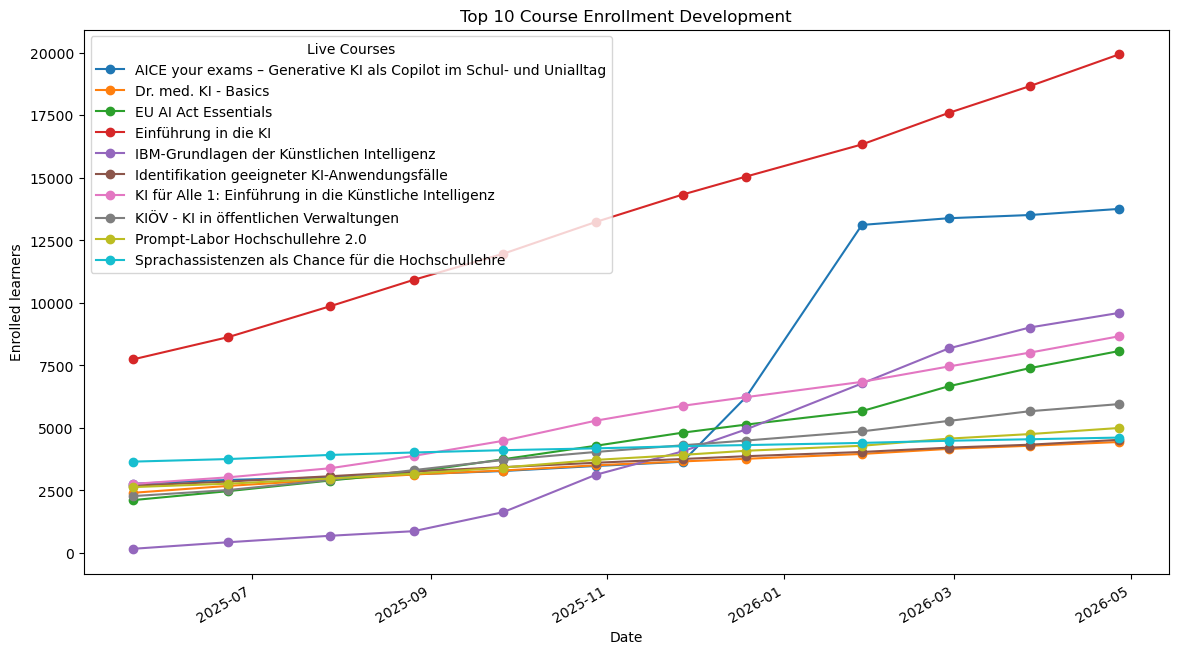

In [28]:
# plot timeseries of the top 10 courses

top10_enrol_allTime_pivot.plot(figsize = (14, 8), marker = 'o')

plt.xlabel('Date')
plt.ylabel('Enrolled learners')
plt.title('Top 10 Course Enrollment Development')
plt.show()
    

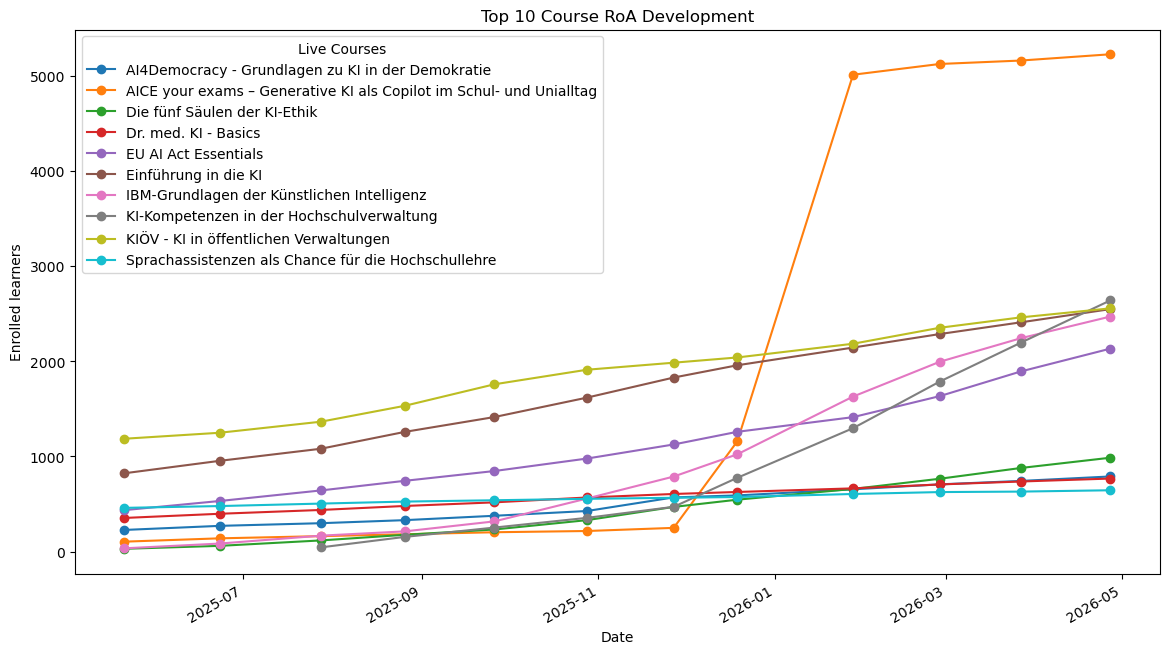

In [29]:
# top10 RoA

top10_RoA_allTime_pivot.plot(figsize = (14, 8), marker = 'o')

plt.xlabel('Date')
plt.ylabel('Enrolled learners')
plt.title('Top 10 Course RoA Development')
plt.show()

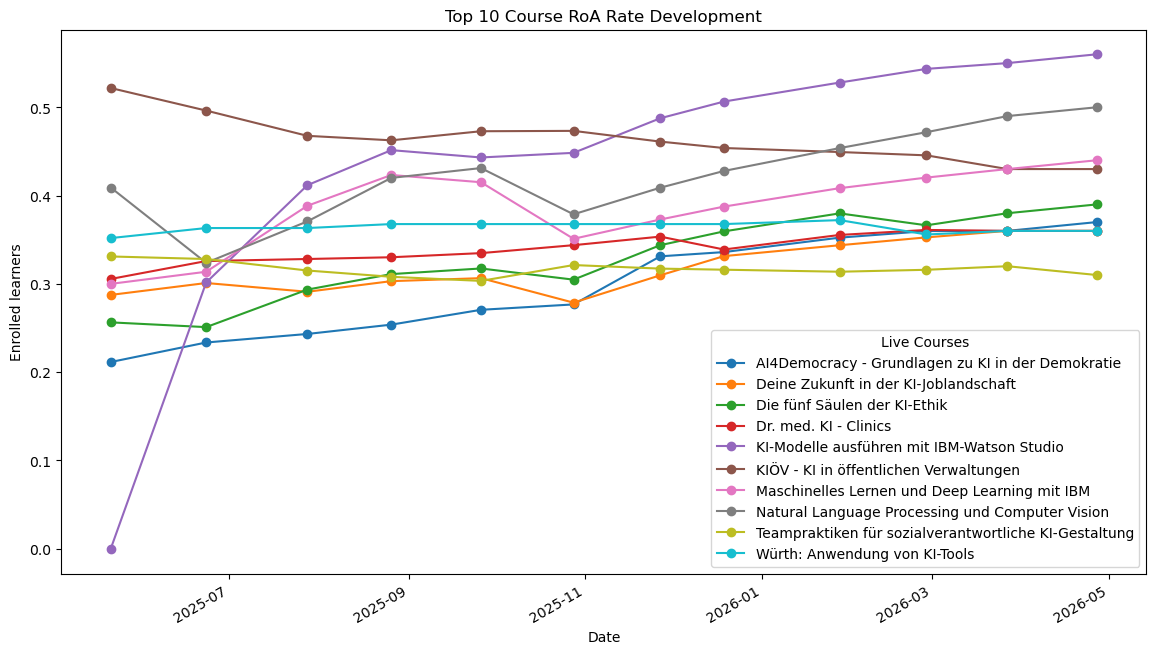

In [30]:
# Top 10 RoA Rate

top10_RoA_rate_allTime_pivot.plot(figsize = (14, 8), marker = 'o')

plt.xlabel('Date')
plt.ylabel('Enrolled learners')
plt.title('Top 10 Course RoA Rate Development')
plt.show()
    

## Analysis per course category

In [31]:
# Aggregation of enrolment per category

print(f"# of total course category: {course_df['Course Category'].nunique()}")

# the number of courses in each category
course_df.groupby('Course Category')['Live Courses'].nunique()


# of total course category: 11


Course Category
Data Literacy           6
Erwachsenenbildung      4
Handel                  1
Industrie 4.0          10
KI und Ethik            6
Maschinelles Lernen    15
Medizin                10
Robotik                 1
Schule                 12
Studieren              19
Über KI                20
Name: Live Courses, dtype: int64

In [32]:
# average course enrolment per category

course_per_cat= pd.DataFrame(course_df.groupby('Course Category').agg(num_courses = ('Live Courses', 'nunique'), avg_enrol = ('Enrolled learners', 'mean'), avg_RoA = ('RoA', 'mean'), avg_RoA_rate = ('Rate RoA', 'mean')))

course_per_cat

,num_courses,avg_enrol,avg_RoA,avg_RoA_rate
Course Category,,,,
Data Literacy,6,1164.728571,217.014493,0.135432
Erwachsenenbildung,4,2721.954545,260.046512,0.069265
Handel,1,1412.416667,223.250000,0.156865
Industrie 4.0,10,1070.066667,88.508475,0.086288
KI und Ethik,6,1131.476923,252.830769,0.234550
Maschinelles Lernen,15,597.045455,65.492188,0.098435
Medizin,10,668.016667,127.933333,0.182880
Robotik,1,712.416667,3.777778,0.003528
Schule,12,669.909722,69.163121,0.123189


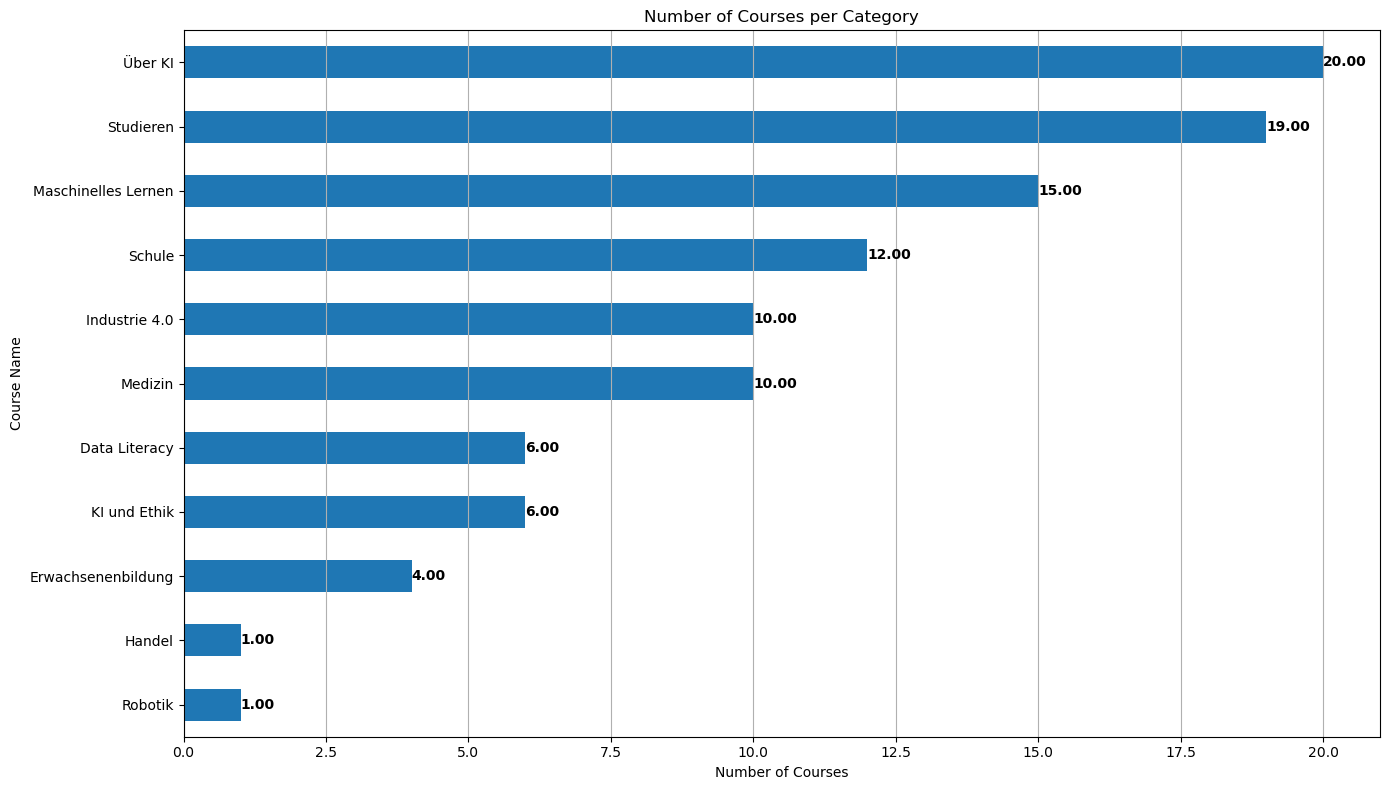

In [33]:
# plotting number of courses per category
plot_topX_horizontal('Number of Courses per Category', course_per_cat['num_courses'], xlabel = 'Number of Courses', x = 11, show_values = True)


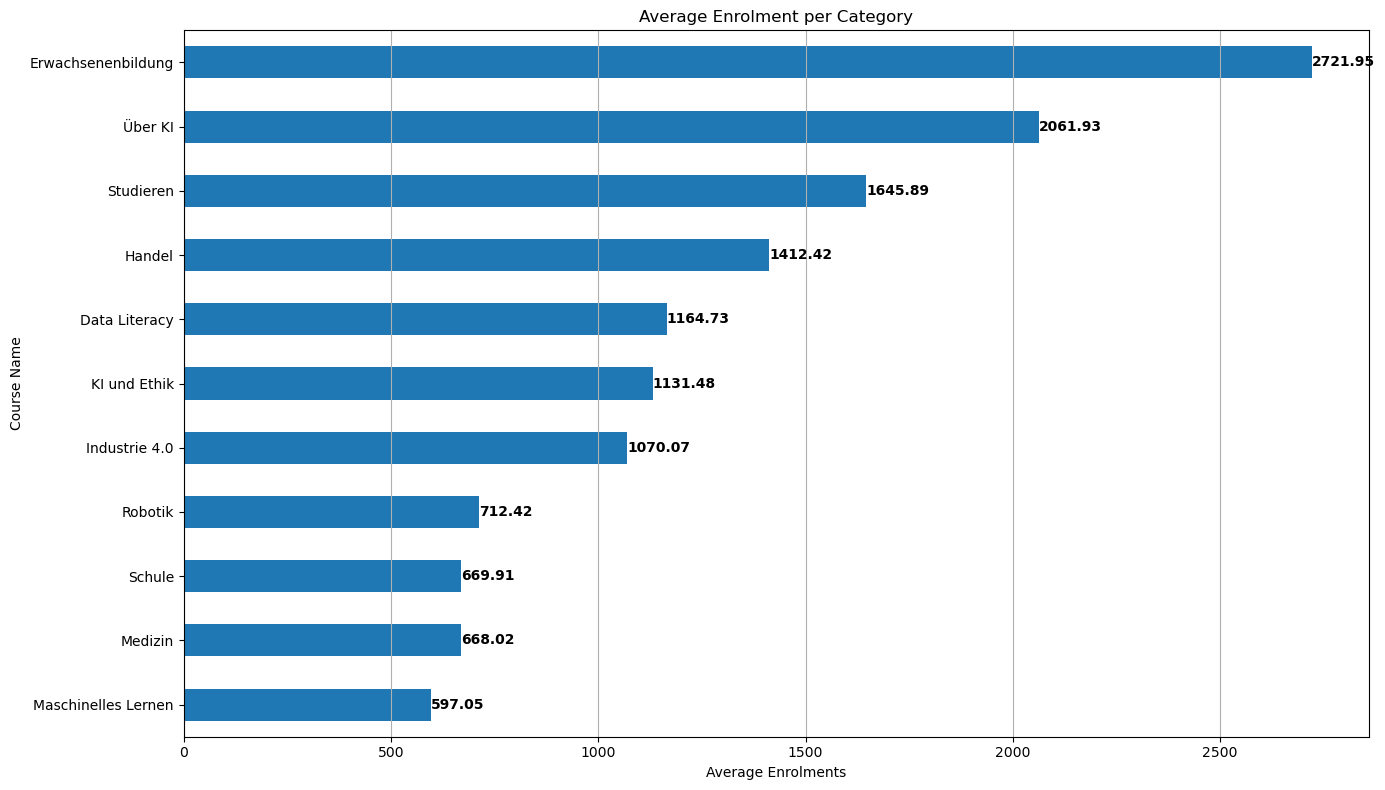

In [34]:
# plotting average enrol per category
plot_topX_horizontal('Average Enrolment per Category', course_per_cat['avg_enrol'], xlabel = 'Average Enrolments', x = 11, show_values = True)


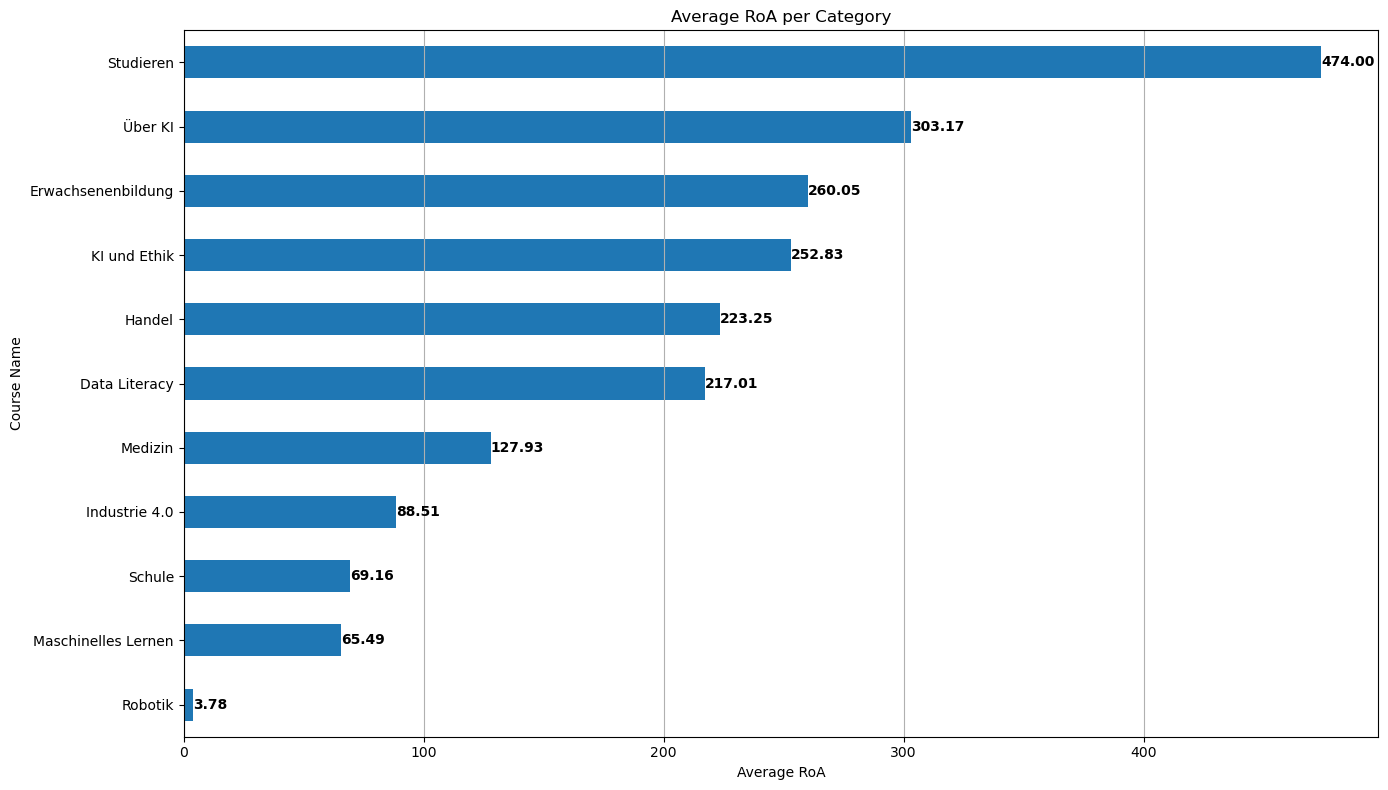

In [35]:
# plotting average RoA per category
plot_topX_horizontal('Average RoA per Category', course_per_cat['avg_RoA'], xlabel = 'Average RoA', x = 11, show_values = True)


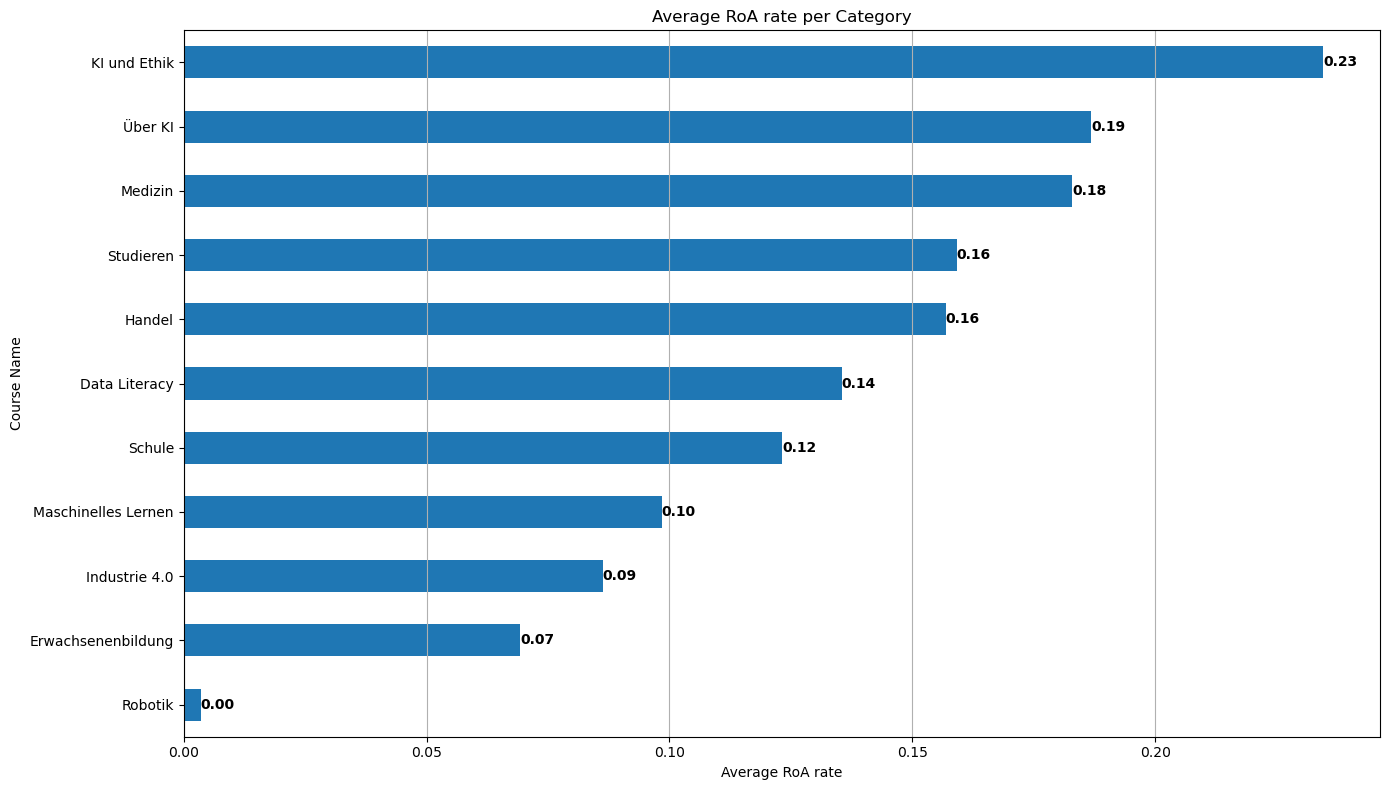

In [36]:
# plot average RoA rate per category
plot_topX_horizontal('Average RoA rate per Category', course_per_cat['avg_RoA_rate'], xlabel = 'Average RoA rate', x = 11, show_values = True)


In [37]:
# enrol per category
corr_per_cat= pd.DataFrame(course_df.groupby('Course Category')[['Enrolled learners', 'RoA', 'Rate RoA']].corr())

corr_per_cat

Enrolled learners       RoA  Rate RoA
Course Category                                                             
Data Literacy       Enrolled learners           1.000000  0.933815  0.555332
                    RoA                         0.933815  1.000000  0.730856
                    Rate RoA                    0.555332  0.730856  1.000000
Erwachsenenbildung  Enrolled learners           1.000000  0.930944  0.886419
                    RoA                         0.930944  1.000000  0.954880
                    Rate RoA                    0.886419  0.954880  1.000000
Handel              Enrolled learners           1.000000  0.981678  0.883142
                    RoA                         0.981678  1.000000  0.953095
                    Rate RoA                    0.883142  0.953095  1.000000
Industrie 4.0       Enrolled learners           1.000000  0.905985 -0.114507
                    RoA                         0.905985  1.000000  0.178619
                    Rate RoA                   -0.114507  0.178619  1.000000
KI und Ethik        Enrolled learners           1.000000  0.661245 -0.169842
                    RoA                         0.661245  1.000000  0.467453
                    Rate RoA                   -0.169842  0.467453  1.000000
Maschinelles Lernen Enrolled learners           1.000000  0.506851  0.103754
                    RoA                         0.506851  1.000000  0.762341
                    Rate RoA                    0.103754  0.762341  1.000000
Medizin             Enrolled learners           1.000000  0.974203  0.071567
                    RoA                         0.974203  1.000000  0.274241
                    Rate RoA                    0.071567  0.274241  1.000000
Robotik             Enrolled learners           1.000000  0.952965  0.924558
                    RoA                         0.952965  1.000000  0.987827
                    Rate RoA                    0.924558  0.987827  1.000000
Schule              Enrolled learners           1.000000  0.823750 -0.276662
                    RoA                         0.823750  1.000000  0.126981
                    Rate RoA                   -0.276662  0.126981  1.000000
Studieren           Enrolled learners           1.000000  0.950066  0.578387
                    RoA                         0.950066  1.000000  0.690307
                    Rate RoA                    0.578387  0.690307  1.000000
Über KI             Enrolled learners           1.000000  0.893229 -0.174688
                    RoA                         0.893229  1.000000  0.106188
                    Rate RoA                   -0.174688  0.106188  1.000000

<Axes: ylabel='Course Category-None'>

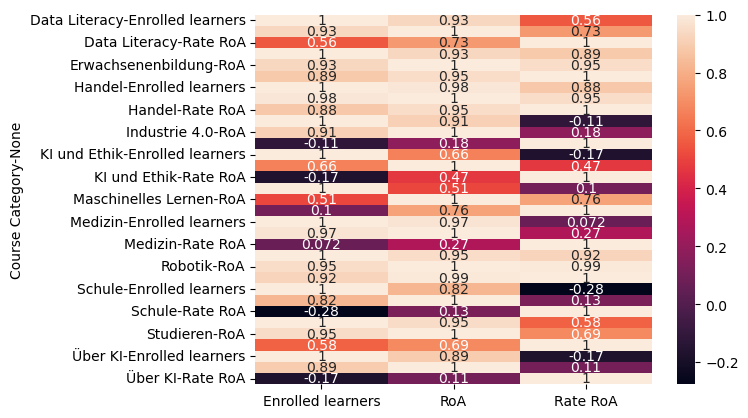

In [38]:
sns.heatmap(corr_per_cat, annot = True)

## Course workload & course language - CoP / RoA investigation

In [39]:
# course workload_language data path

workload_lang_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/workload_lang.csv'

workload_lang = pd.read_csv(workload_lang_path, sep = ';', encoding = 'utf-8')

print(workload_lang.info())

# change the dtype
workload_lang['workload_hrs'] = workload_lang['workload_hrs'].str.replace(',', '.').astype('float32')

workload_lang.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   courseID      98 non-null     int64 
 1   course        98 non-null     object
 2   workload_hrs  95 non-null     object
 3   lang          98 non-null     object
dtypes: int64(1), object(3)
memory usage: 3.2+ KB
None


,courseID,course,workload_hrs,lang
0,106,Einführung in die KI,40.0,DE
1,58,AICE your exams – Generative KI als Copilot im...,7.0,DE
2,99,KI für Alle 1: Einführung in die Künstliche In...,42.0,DE
3,313,EU AI Act Essentials,8.0,DE
4,197,KIÖV - KI in öffentlichen Verwaltungen,5.0,DE


In [40]:
# merge with the course_df

course_workload_lang  = enrol_by_course_id.merge(workload_lang, how = 'left', on = ['courseID'])

course_workload_lang.head()

,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,course,workload_hrs,lang
0,6,Introduction to Machine Learning Part 1: Found...,Maschinelles Lernen,1567.0,86.67,0.06,Introduction to Machine Learning Part 1: Found...,40.0,EN
1,10,Dr. med. KI - Ethics,Medizin,609.0,172.42,0.28,Dr. med. KI - Ethics,21.0,DE
2,19,Sprachassistenzen als Chance für die Hochschul...,Erwachsenenbildung,4188.0,559.42,0.13,Sprachassistenzen als Chance für die Hochschul...,5.0,DE
3,27,Identifikation geeigneter KI-Anwendungsfälle,Industrie 4.0,3636.0,281.92,0.08,Identifikation geeigneter KI-Anwendungsfälle,15.0,DE
4,28,Künstliche Intelligenz im Handel,Handel,1412.0,223.25,0.16,Künstliche Intelligenz im Handel,12.0,DE


In [41]:
# Deal with missing values & exclude course col
course_workload_lang[course_workload_lang['workload_hrs'].isna()]


,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,course,workload_hrs,lang
38,164,Würth: Erweiterte KI-Kompetenz,Über KI,156.0,30.58,0.20,Würth: Erweiterte KI-Kompetenz,NaN,DE
73,248,Würth: Anwendung von KI-Tools,Über KI,226.0,82.08,0.36,Würth: Anwendung von KI-Tools,NaN,DE
74,250,Künstliche Intelligenz im Kontext von Praxis u...,Medizin,79.0,5.92,0.08,Künstliche Intelligenz im Kontext von Praxis u...,NaN,DE


In [42]:
#course_workload_lang = course_workload_lang.drop(['course'], axis = 1)
print(course_workload_lang.shape)
course_workload_lang = course_workload_lang.dropna()
print(course_workload_lang.shape)

course_workload_lang.head()

(104, 9)
(101, 9)


,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,course,workload_hrs,lang
0,6,Introduction to Machine Learning Part 1: Found...,Maschinelles Lernen,1567.0,86.67,0.06,Introduction to Machine Learning Part 1: Found...,40.0,EN
1,10,Dr. med. KI - Ethics,Medizin,609.0,172.42,0.28,Dr. med. KI - Ethics,21.0,DE
2,19,Sprachassistenzen als Chance für die Hochschul...,Erwachsenenbildung,4188.0,559.42,0.13,Sprachassistenzen als Chance für die Hochschul...,5.0,DE
3,27,Identifikation geeigneter KI-Anwendungsfälle,Industrie 4.0,3636.0,281.92,0.08,Identifikation geeigneter KI-Anwendungsfälle,15.0,DE
4,28,Künstliche Intelligenz im Handel,Handel,1412.0,223.25,0.16,Künstliche Intelligenz im Handel,12.0,DE


In [43]:
course_workload_lang = course_workload_lang.drop('course', axis = 1)

course_workload_lang.describe()

,courseID,Avg_enrol,Avg_RoA,Avg_rate_RoA,workload_hrs
count,101.000000,101.000000,101.000000,101.000000,101.000000
mean,199.039604,1154.801980,181.196931,0.130594,25.594059
std,104.569873,1786.330563,354.312026,0.103090,39.086735
min,6.000000,40.000000,0.000000,0.000000,1.500000
25%,109.000000,253.000000,14.880000,0.050000,8.000000
50%,223.000000,609.000000,50.500000,0.110000,12.000000
75%,259.000000,1330.000000,175.880000,0.180000,30.000000
max,406.000000,13685.000000,1911.500000,0.460000,300.000000


In [44]:
# correaltion matrix for numerical variables
num_course_workload = course_workload_lang[['Avg_enrol', 'Avg_RoA', 'Avg_rate_RoA', 'workload_hrs']].corr()

num_course_workload


,Avg_enrol,Avg_RoA,Avg_rate_RoA,workload_hrs
Avg_enrol,1.000000,0.815352,0.101247,-0.062011
Avg_RoA,0.815352,1.000000,0.452391,-0.150334
Avg_rate_RoA,0.101247,0.452391,1.000000,-0.243867
workload_hrs,-0.062011,-0.150334,-0.243867,1.000000


<Axes: >

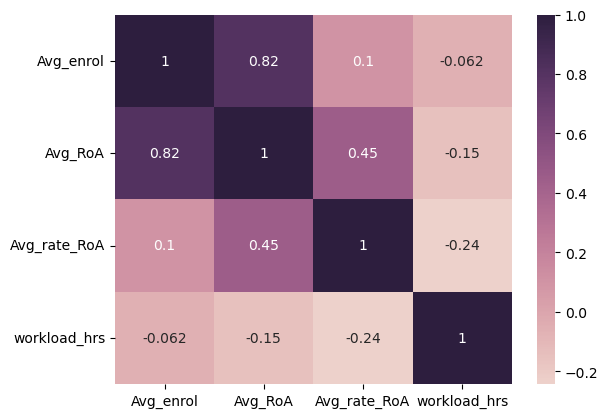

In [45]:
sns.heatmap(num_course_workload, annot = True, cmap = sns.cubehelix_palette(as_cmap=True))

* the average RoA has a strong positive correlation with the average enrolment r = 0.82
* the average RoA rate has a very weak positive correlation with the average enrolment r = 0.10
* the average workload has a very weak negative correlation with the average enrolment r = -0.06
* the average RoA rate has a moderate positive correlation with the average RoA r = 0.45
* the average workload has a weak negative correlation with the average RoA r = -0.15
* the average workload has a weak negative correlation with the average RoA rate r = -0.24


In [50]:
# function - iqr calculator
def iqr_calculator(x):
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr 
    return (iqr, upper, lower)

IQR: 22.0 Upper: 63.0


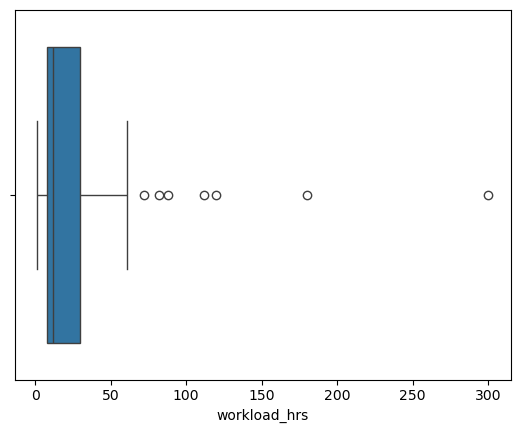

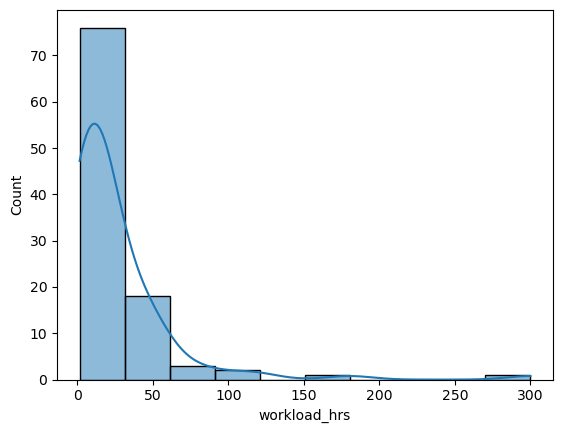

In [51]:
# descriptive stats of the workload distributions and language distributions
print('IQR:', str(iqr_calculator(course_workload_lang['workload_hrs'])[0]), 'Upper:', str(iqr_calculator(course_workload_lang['workload_hrs'])[1]))

sns.boxplot(x = 'workload_hrs', data = course_workload_lang)
plt.show()

sns.histplot(x = 'workload_hrs', data = course_workload_lang, kde = True, bins = 10)
plt.show()

In [83]:
# descriptive stats of the workload distributions by category
workload_cat = pd.DataFrame(course_workload_lang.groupby('Course Category')['workload_hrs'].agg([np.mean, np.std]))

workload_cat['mean'] = round(workload_cat['mean'], 2)
workload_cat['std'] = round(workload_cat['std'], 2)

workload_cat

C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\1148694911.py:2: FutureWarning: The provided callable <function mean at 0x000002088FA47EC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  workload_cat = pd.DataFrame(course_workload_lang.groupby('Course Category')['workload_hrs'].agg([np.mean, np.std]))
C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\1148694911.py:2: FutureWarning: The provided callable <function std at 0x000002088FA54040> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  workload_cat = pd.DataFrame(course_workload_lang.groupby('Course Category')['workload_hrs'].agg([np.mean, np.std]))


,mean,std
Course Category,,
Data Literacy,20.83,16.170000
Erwachsenenbildung,9.25,3.400000
Handel,12.00,NaN
Industrie 4.0,27.10,21.549999
KI und Ethik,4.75,4.540000
Maschinelles Lernen,42.57,35.930000
Medizin,24.00,18.790001
Robotik,180.00,NaN
Schule,41.75,82.980003


*  ML courses and Robotic course has the highest average course workload.
*  The adult education courses have the least average course workload. 
*  Except for the Schule courses, most of the courses are within the 10 - 25 hrs workload

In [86]:
# descriptive stats of the workload distributions by language
workload_language = pd.DataFrame(course_workload_lang.groupby('lang')['workload_hrs'].agg([np.mean, np.std]))

workload_language['mean'] = round(workload_language['mean'], 2)
workload_language['std'] = round(workload_language['std'], 2)

print(workload_language)


           mean        std
lang                      
DE    22.200001  38.150002
EN    32.919998  40.680000


C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\1730254138.py:2: FutureWarning: The provided callable <function mean at 0x000002088FA47EC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  workload_language = pd.DataFrame(course_workload_lang.groupby('lang')['workload_hrs'].agg([np.mean, np.std]))
C:\Users\ywa\AppData\Local\Temp\ipykernel_23248\1730254138.py:2: FutureWarning: The provided callable <function std at 0x000002088FA54040> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  workload_language = pd.DataFrame(course_workload_lang.groupby('lang')['workload_hrs'].agg([np.mean, np.std]))


### Do courses in different languages perform differently?

Text(0.5, 1.0, 'Average Enrolment in English and German courses')

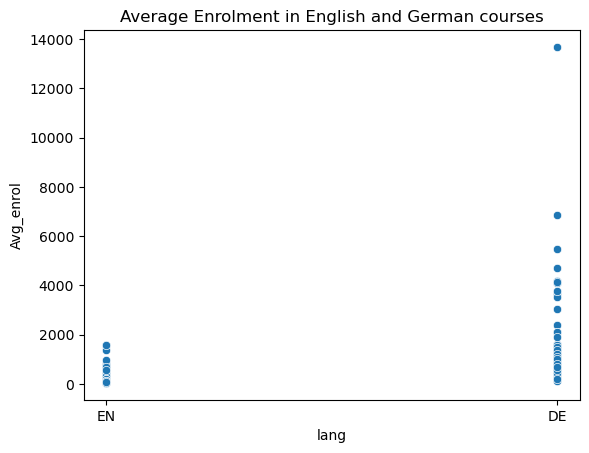

In [74]:
sns.scatterplot(x = 'lang', y = 'Avg_enrol', data = course_workload_lang)
plt.title("Average Enrolment in English and German courses")

Text(0.5, 1.0, 'Average RoA obtained in English and German courses')

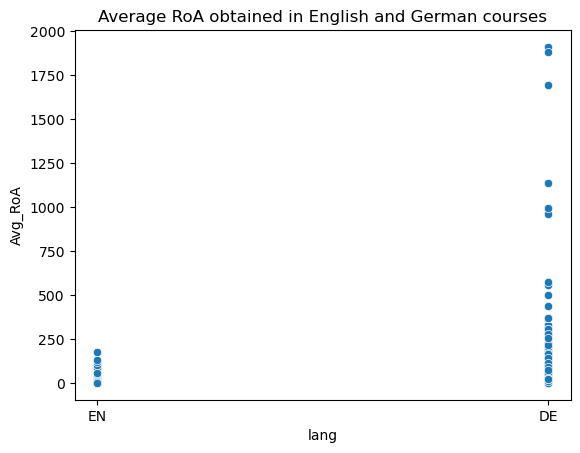

In [75]:
sns.scatterplot(x = 'lang', y = 'Avg_RoA', data = course_workload_lang)
plt.title("Average RoA obtained in English and German courses")

Text(0.5, 1.0, 'Average RoA rate in English and German courses')

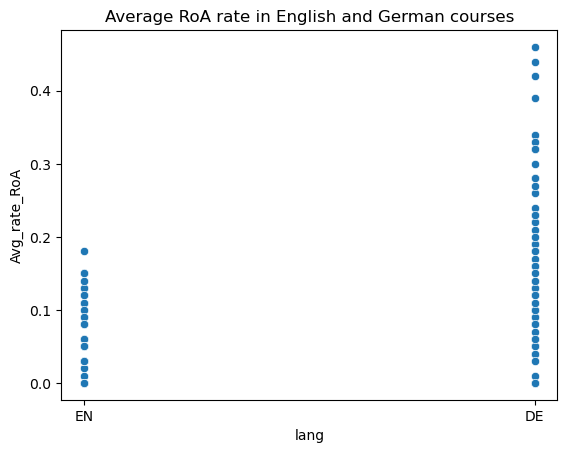

In [76]:
sns.scatterplot(x = 'lang', y = 'Avg_rate_RoA', data = course_workload_lang)
plt.title("Average RoA rate in English and German courses")

## Cluster analysis

In [54]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [55]:
# import dependencies
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [56]:
# feature selection 
course_workload_lang.head()

cluster_feature = course_workload_lang.drop(['courseID', 'Live Courses'], axis = 1)

cluster_feature.info()


<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Course Category  101 non-null    object 
 1   Avg_enrol        101 non-null    float64
 2   Avg_RoA          101 non-null    float64
 3   Avg_rate_RoA     101 non-null    float64
 4   workload_hrs     101 non-null    float32
 5   lang             101 non-null    object 
dtypes: float32(1), float64(3), object(2)
memory usage: 5.1+ KB


In [57]:
# encoding scaling data via column transformer

preprocess = ColumnTransformer(transformers = [('categorical', OneHotEncoder(drop = 'if_binary'), ['Course Category', 'lang']), 
                                               ('numerical', StandardScaler(), ['Avg_enrol', 'Avg_RoA', 'Avg_rate_RoA', 'workload_hrs'])])



In [58]:
# setup param_finder function
random_state = 777

def param_finder(n_list, k_list, random_state, features):
    best_score = -1
    best_param = None
    results = []
    for n in n_list:
        pca = PCA(n_components = n, random_state = random_state)
        X_reduced = pca.fit_transform(features)
        
        for k in k_list:
            kmeans = KMeans(n_clusters = k, random_state = random_state, n_init = 20)
            labels = kmeans.fit_predict(X_reduced)
            
            score = silhouette_score(X_reduced, labels)
            results.append((n, k, score))
            
            if score > best_score:
                best_score = score
                best_param = {'n_components' : n, 'k' : k}
    return best_score, best_param, results

In [59]:
# iterate features through function

features = preprocess.fit_transform(cluster_feature)

print(features.shape)

n_list = np.arange(5, 20, 5)
k_list = range(2, 9)

best_score, best_param, results = param_finder(n_list, k_list, random_state, features)

print(best_score, best_param)


(101, 16)
0.5970448650066787 {'n_components': np.int64(5), 'k': 2}


In [60]:
# build pipeline PCA + KMeans --> feed the best hyperparam here

num_components = best_param['n_components']
k = best_param['k']

pipe = Pipeline([('preprocess', preprocess), 
                 ('pca', PCA(n_components = num_components)), 
                 ('kmeans', KMeans(n_clusters = k, n_init = 20, random_state = random_state ))])

labels = pipe.fit_predict(cluster_feature)

labels.shape


(101,)

In [61]:
# cluster stability
# interate the clustring with different random seeds calculate the Adjusted Rand Index (ARI)
# aim for ARI close to 1 (identical clustering)
# fucntion to get labels

def get_labels(X, n_components, k, runs = 20):
    label_list = []
    
    for seed in range(runs):
        pipe = Pipeline(steps = [('pca', PCA(n_components = n_components, random_state = seed)), 
                                ('kmeans', KMeans(n_clusters = k, random_state = seed, n_init = 20))])
        
        labels = pipe.fit_predict(X)
        label_list.append(labels)
    return label_list
 
def ari_calculator(label_list):
    n = len(label_list)
    ari_scores = []
    
    for i in range(n):
        for j in range(i + 1, n):
            ari = adjusted_rand_score(label_list[i], label_list[j])
            ari_scores.append(ari)
            
    return np.mean(ari_scores), np.std(ari_scores)


label_list = get_labels(features, best_param['n_components'], best_param['k'], runs = 20)
avg, std = ari_calculator(label_list)

print(f"average: {avg}, std: {std}")

average: 1.0, std: 0.0


In [62]:
# interpretation by bringing back the clusters back to the oringinal high dimensions
pca = pipe.named_steps['pca']
kmeans= pipe.named_steps['kmeans']

# get original centroids
centroids = pca.inverse_transform(kmeans.cluster_centers_)
print(centroids.shape)

(2, 16)


In [63]:
# inteprete within dataframe
centroids_df = pd.DataFrame(centroids, columns = preprocess.get_feature_names_out())

centroids_df


,categorical__Course Category_Data Literacy,categorical__Course Category_Erwachsenenbildung,categorical__Course Category_Handel,categorical__Course Category_Industrie 4.0,categorical__Course Category_KI und Ethik,categorical__Course Category_Maschinelles Lernen,categorical__Course Category_Medizin,categorical__Course Category_Robotik,categorical__Course Category_Schule,categorical__Course Category_Studieren,categorical__Course Category_Über KI,categorical__lang_EN,numerical__Avg_enrol,numerical__Avg_RoA,numerical__Avg_rate_RoA,numerical__workload_hrs
0,0.058782,0.036946,0.009729,0.105015,0.058584,0.160577,0.093184,0.010565,0.128237,0.163947,0.174433,0.333251,-0.188514,-0.209129,-0.078849,0.023787
1,0.069287,0.081689,0.012618,0.003927,0.072414,-0.042469,0.024594,-0.000606,-0.030424,0.570832,0.238137,0.056863,2.984798,3.311209,1.248449,-0.376622


In [64]:
# compare with cluster frequency
features_df = pd.DataFrame(features, columns = preprocess.get_feature_names_out())

features_df['labels'] = labels
cluster_profiles = features_df.groupby('labels').mean()

cluster_profiles

,categorical__Course Category_Data Literacy,categorical__Course Category_Erwachsenenbildung,categorical__Course Category_Handel,categorical__Course Category_Industrie 4.0,categorical__Course Category_KI und Ethik,categorical__Course Category_Maschinelles Lernen,categorical__Course Category_Medizin,categorical__Course Category_Robotik,categorical__Course Category_Schule,categorical__Course Category_Studieren,categorical__Course Category_Über KI,categorical__lang_EN,numerical__Avg_enrol,numerical__Avg_RoA,numerical__Avg_rate_RoA,numerical__workload_hrs
labels,,,,,,,,,,,,,,,,
0,0.052632,0.042105,0.010526,0.105263,0.063158,0.157895,0.094737,0.010526,0.126316,0.168421,0.168421,0.336842,-0.175360,-0.223743,-0.072492,0.024105
1,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.333333,0.000000,2.776537,3.542590,1.147793,-0.381666


In [65]:
# get top 5 features --> what contribute to the difference
for i, row in centroids_df.iterrows():
    print(f"\nCluster{i} in pre set")
    print(row.sort_values(ascending = False).head(5))


Cluster0 in pre set
categorical__lang_EN                                0.333251
categorical__Course Category_Über KI                0.174433
categorical__Course Category_Studieren              0.163947
categorical__Course Category_Maschinelles Lernen    0.160577
categorical__Course Category_Schule                 0.128237
Name: 0, dtype: float64

Cluster1 in pre set
numerical__Avg_RoA                        3.311209
numerical__Avg_enrol                      2.984798
numerical__Avg_rate_RoA                   1.248449
categorical__Course Category_Studieren    0.570832
categorical__Course Category_Über KI      0.238137
Name: 1, dtype: float64


In [66]:
# get importance (cluster mean - global mean)
global_mean = features_df.mean()

importance = cluster_profiles - global_mean

for i, row in importance.iterrows():
    print(f"\nCluster{i} in pre set (importance)")
    print(row.sort_values(ascending = False).head(5))


Cluster0 in pre set (importance)
numerical__workload_hrs                             0.024105
categorical__lang_EN                                0.020010
categorical__Course Category_Maschinelles Lernen    0.009380
categorical__Course Category_Schule                 0.007504
categorical__Course Category_Industrie 4.0          0.006253
Name: 0, dtype: float64

Cluster1 in pre set (importance)
numerical__Avg_RoA                        3.542590
numerical__Avg_enrol                      2.776537
numerical__Avg_rate_RoA                   1.147793
categorical__Course Category_Studieren    0.311881
categorical__Course Category_Über KI      0.155116
Name: 1, dtype: float64


In [67]:
# plotting with TSNE
pca4embed = PCA(n_components = 5)

embed = pca4embed.fit_transform(features)
tsne = TSNE(n_components = 2, learning_rate = 'auto', init = 'pca', 
                 perplexity = 30, random_state = random_state).fit_transform(embed)


In [68]:
# plotting function
def plotting_clusters(labels, tsne):
    plt.figure()
    plt.scatter(tsne[:, 0], tsne[:, 1], c = labels, s = 8) # plotting points
    # plotting centroids (median)
    for c in np.unique(labels):
        pts = tsne[labels == c]
        centre = np.median(pts, axis = 0)
        plt.scatter(centre[0], centre[1], s = 250, marker = 'X')
        plt.text(centre[0], centre[1], f"C{c}", fontsize = 12, color = 'red', fontweight = 'bold')
    plt.title('t-SNE with Cluster Centres (median in t-SNE space)')
    plt.show()


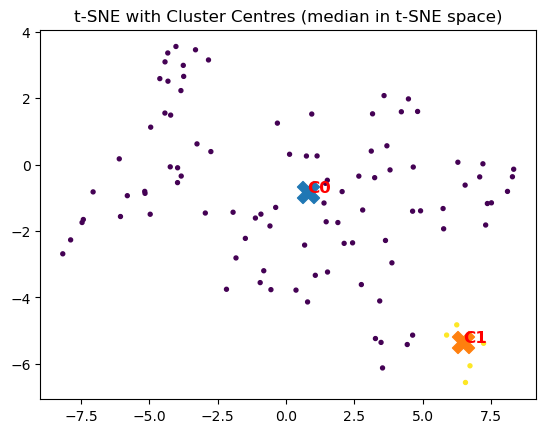

In [69]:
plotting_clusters(labels, tsne)

In [70]:
#  check labels
np.bincount(labels)

array([95,  6])

In [71]:
# zoom in on the outlier group
course_workload_lang['labels'] = labels

outliers = course_workload_lang.loc[course_workload_lang['labels'] == 1]

outliers

,courseID,Live Courses,Course Category,Avg_enrol,Avg_RoA,Avg_rate_RoA,workload_hrs,lang,labels
11,58,AICE your exams – Generative KI als Copilot im...,Studieren,6854.0,1911.50,0.18,7.0,DE,1
24,106,Einführung in die KI,Über KI,13685.0,1693.50,0.12,40.0,DE,1
44,197,KIÖV - KI in öffentlichen Verwaltungen,Studieren,4111.0,1881.58,0.46,5.0,DE,1
86,313,EU AI Act Essentials,Studieren,4707.0,1136.50,0.24,8.0,DE,1
88,322,IBM-Grundlagen der Künstlichen Intelligenz,Über KI,4123.0,960.42,0.22,1.5,DE,1
96,360,KI-Kompetenzen in der Hochschulverwaltung,Data Literacy,3060.0,997.40,0.27,3.0,DE,1
